# Econ 372 — Homework

Damir Penaranda

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# The data lives in the data/ folder at the top of the repo. From this
# notebook (inside code/), that is one level up, for example:
# df = pd.read_csv('../data/your-data-file.csv')

## Question 1

Write your code and your answer here.

In [28]:
df = pd.read_csv('../data/new-jersey-insurance-data.csv')
print(df)

   Year  Horizon BCBS of NJ  Aetna Life Insurance Company  \
0  2000             1676.90                        2949.0   
1  2001             2072.39                        4312.0   
2  2002             2765.07                        4266.0   
3  2003             3573.71                        4266.0   
4  2004             4437.96                        4390.0   
5  2005             5006.02                        4390.0   
6  2006             3198.98                        4664.0   
7  2007             3678.84                        5233.0   
8  2008             4230.65                        5976.0   

   Celtic Insurance Company  Standard Enrollment  
0                    2551.0               104448  
1                    3188.0                89653  
2                    4003.0                79682  
3                    7843.0                76937  
4                    7843.0                75662  
5                    7843.0                71398  
6                    7843.0     


Write your code and your answer here.

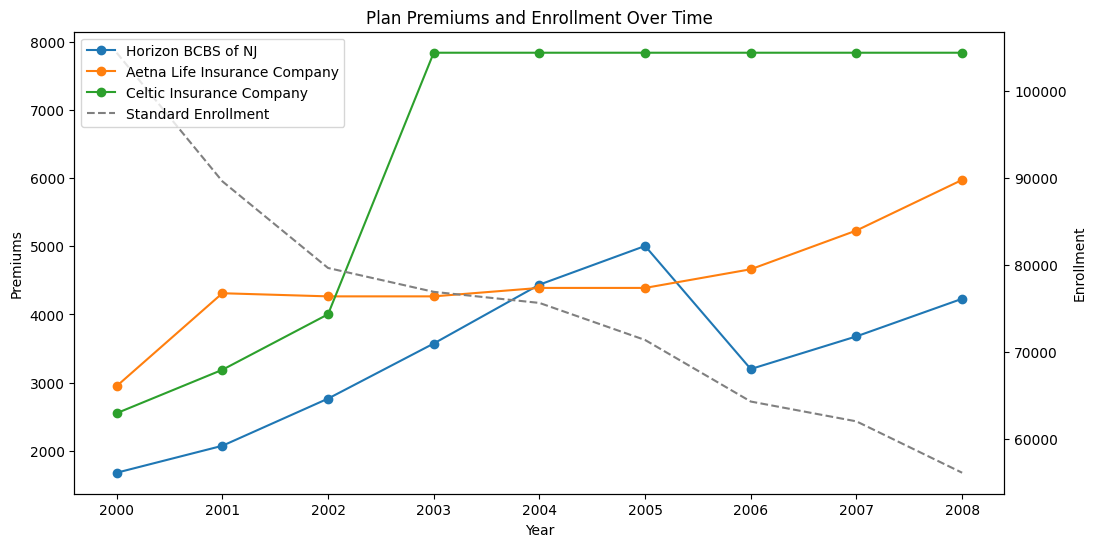

In [29]:
plt.figure(figsize=(12, 6))

ax1 = plt.gca()

ax1.plot(df['Year'], df['Horizon BCBS of NJ'],
         label='Horizon BCBS of NJ', marker='o')

ax1.plot(df['Year'], df['Aetna Life Insurance Company'],
         label='Aetna Life Insurance Company', marker='o')

ax1.plot(df['Year'], df['Celtic Insurance Company'],
         label='Celtic Insurance Company', marker='o')

ax2 = ax1.twinx()

ax2.plot(df['Year'], df['Standard Enrollment'],
         label='Standard Enrollment', color='gray', linestyle='--')

plt.title('Plan Premiums and Enrollment Over Time')

ax1.set_xlabel('Year')
ax1.set_ylabel('Premiums')
ax2.set_ylabel('Enrollment')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

Question B: This data shows the premiums increasing overall across all 3 plans from 2000-2008. Although there are some notable fluctations like like the 2006-06 decline of Horizon, the data still shows that premiums have generally increased over time, while at the same time enrollment has dropped by nearly half. This graph suggests a negative corrleation between enrollment and premium price.

Question C. This pattern can suggest adverse selection as sicker individuals with higher expected  costs are more likely to remain enrolled despite rising premiums than healthier individuals with lower expected costs. While as monthly premiums increase, healthier individuals will likely switch to cheaper plans or exit the insurance market altogether. This raises insurers average cost to cover an additonal patient, and in response insurance companies are forced to raise prices. This shows the asymmetry in the market, and the advantage that patients have as they know more about their health than insurers do.

Question D: Yes, I believe the rising premiums and lowered enrollment rates suggest adverse selection and indications of a death spiral. Primailly because even in years when premiums lowered like Horizon in 2005 and 2006, enrollment rates continued to drop. Additinanlly, when looking at Celtic, their premium rate has remianed constant for 5 years yet enrollment has conitnued to tank.

Question 2

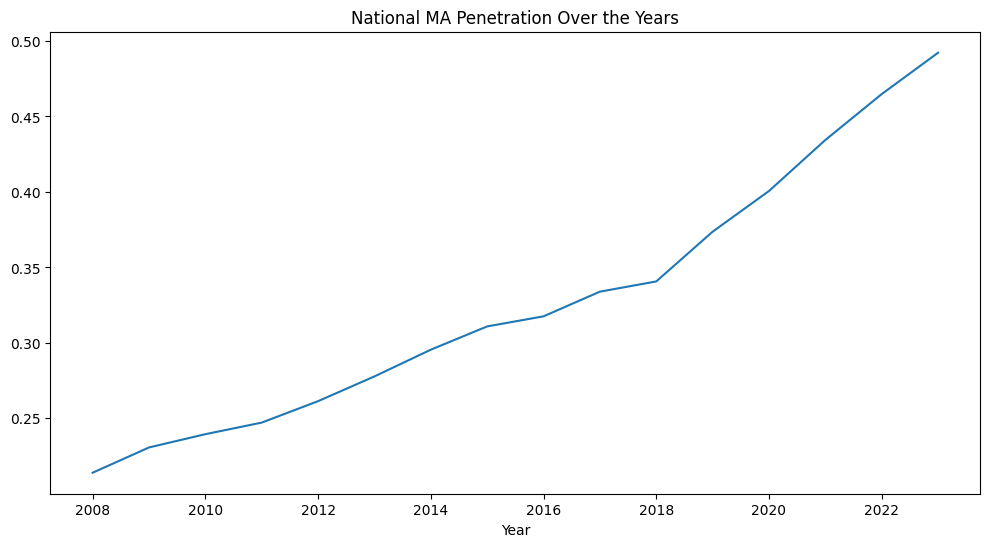

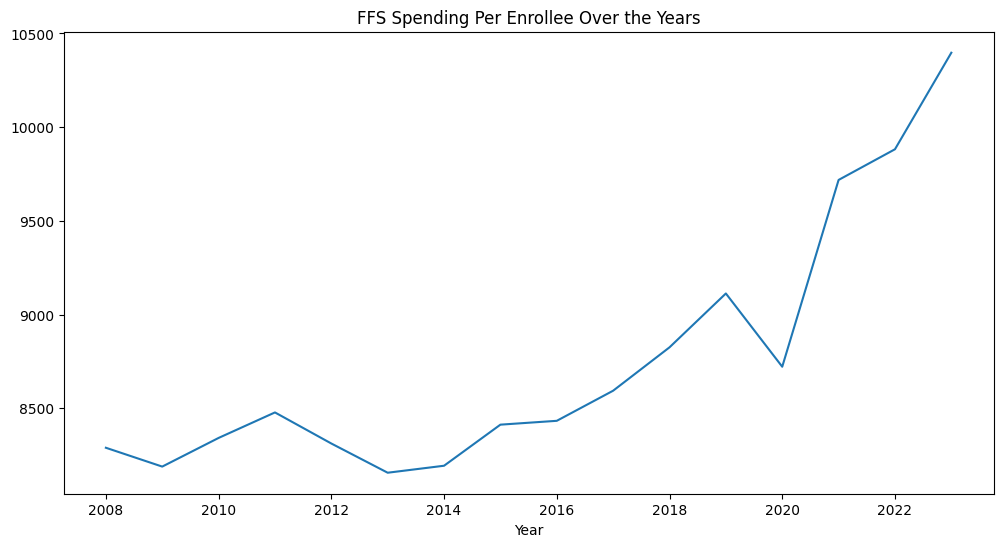

In [30]:
ma_penetration = pd.read_csv('../data/medicare-ma-penetration.csv')

ffs_costs = pd.read_csv('../data/medicare-ffs-costs.csv')

merged_data = pd.merge(ma_penetration, ffs_costs, on=['county', 'year'], how='inner')

national_totals = merged_data.groupby('year').sum(numeric_only=True).reset_index()


national_totals['ma_penetration'] = national_totals['ma_enrolled'] / national_totals['total_eligibles']
national_totals['ffs_spending_per_enrollee'] = national_totals['ffs_spending'] / national_totals['ffs_enrollment']

plt.figure(figsize=(12, 6))
plt.plot(national_totals['year'], national_totals['ma_penetration'])
plt.title('National MA Penetration Over the Years')
plt.xlabel('Year')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(national_totals['year'], national_totals['ffs_spending_per_enrollee'])
plt.title('FFS Spending Per Enrollee Over the Years')
plt.xlabel('Year')
plt.show()

These graphs allign with what we have discussed, showing how Medicare Advantage plans have grown to become nearly half (and now more than half) of all total Medicare plans. Over the same period, FFS spending per enrollee has also risen sharply, which also lines up with what the textbook noted. MA plans tend to be more "efficient" in resource allocation, yet total Medicare spending remains high because those efficiency savings are not captured by taxpayers. Instead, the savings are captured in part by beneficiaries and, even more by the insurers themselves.

Question B: This pattern is consistent with the favorable selection we discussed in class. Essentially, healthier, lower-cost beneficiaries are more likely to switch into Medicare Advantage plans, leaving a smaller, sicker, and more expensive population behind in traditional FFS. Thus, as the FFS pool grows sicker, average spending per enrollee grows.

Question C: Risk adjustment is the system CMS uses to pay Medicare Advantage plans based on the expected health risk of their enrollees. The system rewards insurance plans that have "sicker" patients with higher expected costs with more money. This system helps address favorable selection by insurers as without it, insurers would have a strong incentive to design plans and marketing that attract healthy, low-cost enrollees while avoiding sicker ones. 

Question D: Another tool to curb adverse selection is the coding intensity adjustment. This is a statutory downward adjustment (minimum 5.9%) that CMS applies to MA risk scores to correct for MA plans reporting diagnoses more thoroughly than FFS, which inflates risk scores and payments by as much as 16-20% before adjustment. This matters because more intensive coding can drive plan profits, undermining risk adjustment's goal of neutralizing selection incentives. This helps offset inflated payments, keeping MA payments closer to true comparable FFS costs rather than rewarding overcoding.

Source: https://www.kff.org/medicare/decoding-medicare-advantage-coding-intensity/
